# Heart Disease Prediction - Machine Learning Project

**DS 400: Data Science Techniques I**  
**Mount Mercy University - Fall 2025**  
**Semester Project**

---

## Table of Contents
1. [Problem Definition](#1-problem-definition)
2. [Data Collection](#2-data-collection)
3. [Data Preparation](#3-data-preparation)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Modeling](#5-modeling)
6. [Model Evaluation](#6-model-evaluation)
7. [Conclusions and Future Work](#7-conclusions-and-future-work)


---

## 1. Problem Definition

### Business Understanding

**Problem Statement:**

Heart disease is the leading cause of death globally, accounting for approximately 17.9 million deaths annually according to the World Health Organization. Early detection and prediction of heart disease can significantly improve patient outcomes by enabling timely medical intervention and preventive care. This project aims to develop a machine learning model that can predict the presence of heart disease in patients based on various clinical, demographic, and lifestyle factors.

**Problem Type:**

This is a **binary classification problem** where we predict whether a patient has heart disease (1) or does not have heart disease (0).

**Why is this problem important?**

- **Early Detection**: Machine learning models can identify high-risk patients before symptoms become severe, enabling preventive interventions
- **Resource Optimization**: Helps healthcare providers prioritize patients who need immediate attention, improving resource allocation
- **Cost Reduction**: Reduces unnecessary tests and hospitalizations through better risk assessment
- **Improved Outcomes**: Early intervention can significantly improve patient survival rates and quality of life
- **Public Health Impact**: Can be used for population-level health screening and awareness programs

**Data-Driven Approach:**

By analyzing patterns in patient data (age, BMI, blood pressure, lifestyle factors, medical history, etc.), we can build predictive models that assist healthcare professionals in making informed decisions about patient care. Machine learning algorithms can identify complex relationships and risk factors that may not be immediately apparent through traditional statistical methods.


---

## 2. Data Collection

### Dataset Information

**Dataset Source:** Heart Disease Health Indicators Dataset (Kaggle)  
**Dataset Link:** https://www.kaggle.com/datasets/alexteboul/heart-disease-health-indicators-dataset  
**Data Format:** CSV file  
**Dataset Size:** 229,781 records, 18 features  
**Usage:** We will use the full dataset (229,781 records) for comprehensive analysis and robust model training

**Dataset Description:**

This dataset is derived from the 2015 Behavioral Risk Factor Surveillance System (BRFSS) survey conducted by the Centers for Disease Control and Prevention (CDC). The BRFSS is the world's largest, continuously conducted health survey system, collecting data on health-related risk behaviors, chronic health conditions, and use of preventive services.

**Key Dataset Features:**

1. **HeartDisease** - Target variable: Ever told you had heart disease (Yes/No)
2. **BMI** - Body Mass Index
3. **Smoking** - Have you smoked at least 100 cigarettes in your entire life?
4. **AlcoholDrinking** - Heavy drinkers (adult men >=14 drinks/week, adult women >=7 drinks/week)
5. **Stroke** - Ever told you had a stroke
6. **PhysicalHealth** - Physical health (days with poor physical health in last 30 days)
7. **MentalHealth** - Mental health (days with poor mental health in last 30 days)
8. **DiffWalking** - Do you have serious difficulty walking or climbing stairs?
9. **Sex** - Sex (Male/Female)
10. **AgeCategory** - Age category (13-level age groups)
11. **Race** - Race/Ethnicity
12. **Diabetic** - Ever told you had diabetes
13. **PhysicalActivity** - Physical activity in past 30 days
14. **GenHealth** - General health (Excellent, Very good, Good, Fair, Poor)
15. **SleepTime** - Hours of sleep per day
16. **Asthma** - Ever told you had asthma
17. **KidneyDisease** - Ever told you had kidney disease
18. **SkinCancer** - Ever told you had skin cancer

**Dataset Limitations:**

- Self-reported data may contain biases and inaccuracies
- Some features may have missing values that require handling
- Dataset from 2015 may not reflect current medical standards or population characteristics

- Geographic and demographic representation may vary


### Importing Required Libraries


In [40]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully.")


Libraries imported successfully.


### Loading the Dataset


In [41]:
# Load the dataset
# Note: Download the dataset from Kaggle and save as 'heart_disease_health_indicators_BRFSS2015.csv'
# We will use the FULL dataset (229,781 records) for comprehensive analysis

try:
    # Load the full dataset
    print("Loading dataset...")
    df = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv')
    print(f"Dataset loaded successfully. Full dataset size: {df.shape}")
    
except FileNotFoundError:
    print("ERROR: Dataset file not found!")
    print("\nPlease download the dataset from Kaggle:")
    print("1. Visit: https://www.kaggle.com/datasets/alexteboul/heart-disease-health-indicators-dataset")
    print("2. Click 'Download' button")
    print("3. Extract the ZIP file")
    print("4. Save 'heart_disease_health_indicators_BRFSS2015.csv' in this directory")
    raise

# Standardize target column name
# Check for different possible target column names
print("\nChecking for target column...")
print(f"Available columns: {list(df.columns)[:5]}...")  # Show first 5 columns

if 'HeartDisease' in df.columns:
    print("Found 'HeartDisease' column")
    if df['HeartDisease'].dtype == 'object':
        df['target'] = df['HeartDisease'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})
    else:
        df['target'] = df['HeartDisease'].astype(int)
    df = df.drop('HeartDisease', axis=1)
elif 'HeartDiseaseorAttack' in df.columns:
    print("Found 'HeartDiseaseorAttack' column")
    # This dataset uses 1.0 for Yes and 0.0 for No
    df['target'] = df['HeartDiseaseorAttack'].astype(int)
    df = df.drop('HeartDiseaseorAttack', axis=1)
else:
    # Try to find any column that might be the target
    target_candidates = [col for col in df.columns if 'heart' in col.lower() or 'disease' in col.lower()]
    if target_candidates:
        print(f"Found potential target column: {target_candidates[0]}")
        df['target'] = df[target_candidates[0]]
        if df['target'].dtype == 'object':
            df['target'] = df['target'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})
        else:
            df['target'] = df['target'].astype(int)
        df = df.drop(target_candidates[0], axis=1)
    else:
        raise ValueError("Could not find target column in dataset. Available columns: " + str(list(df.columns)))

print("Target column created successfully.")

# Display basic information
print(f"\n{'='*60}")
print(f"Dataset Information:")
print(f"  Shape: {df.shape}")
print(f"  Samples: {df.shape[0]:,}")
print(f"  Features: {df.shape[1] - 1}")
print(f"{'='*60}")

# Verify target column was created
if 'target' in df.columns:
    target_dist = df['target'].value_counts(normalize=True) * 100
    target_counts = df['target'].value_counts()
    print(f"\nTarget distribution:")
    print(f"  No disease (0): {target_counts.get(0, 0):,} ({target_dist.get(0, 0):.1f}%)")
    print(f"  Disease (1): {target_counts.get(1, 0):,} ({target_dist.get(1, 0):.1f}%)")
    
    # Check for class imbalance
    if len(target_dist) > 0:
        min_class_pct = target_dist.min()
        if min_class_pct < 10:
            print(f"\nNote: Significant class imbalance detected (minority class: {min_class_pct:.1f}%).")
            print("Consider using class_weight='balanced' or SMOTE for better results.")
        elif min_class_pct < 20:
            print(f"\nNote: Moderate class imbalance detected (minority class: {min_class_pct:.1f}%).")
        else:
            print(f"\nClasses are reasonably balanced.")
else:
    print("\nWARNING: Target column was not created successfully!")
    print(f"Available columns: {list(df.columns)}")

print(f"\nFirst few rows:")
df.head()


Loading dataset...
Dataset loaded successfully. Full dataset size: (253680, 22)

Checking for target column...
Available columns: ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI']...
Found 'HeartDiseaseorAttack' column
Target column created successfully.

Dataset Information:
  Shape: (253680, 22)
  Samples: 253,680
  Features: 21

Target distribution:
  No disease (0): 229,787 (90.6%)
  Disease (1): 23,893 (9.4%)

Note: Significant class imbalance detected (minority class: 9.4%).
Consider using class_weight='balanced' or SMOTE for better results.

First few rows:


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,target
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,0


---

## 3. Data Preparation

### 3.1 Initial Data Inspection


In [42]:
# Basic information about the dataset
print("Dataset Info:")
print("=" * 60)
df.info()

print("\n\nDataset Statistics:")
print("=" * 60)
df.describe()

print("\n\nData Types:")
print("=" * 60)
print(df.dtypes.value_counts())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   HighBP             253680 non-null  float64
 1   HighChol           253680 non-null  float64
 2   CholCheck          253680 non-null  float64
 3   BMI                253680 non-null  float64
 4   Smoker             253680 non-null  float64
 5   Stroke             253680 non-null  float64
 6   Diabetes           253680 non-null  float64
 7   PhysActivity       253680 non-null  float64
 8   Fruits             253680 non-null  float64
 9   Veggies            253680 non-null  float64
 10  HvyAlcoholConsump  253680 non-null  float64
 11  AnyHealthcare      253680 non-null  float64
 12  NoDocbcCost        253680 non-null  float64
 13  GenHlth            253680 non-null  float64
 14  MentHlth           253680 non-null  float64
 15  PhysHlth           253680 non-null  f

### 3.2 Handling Missing Values


In [43]:
# Check for missing values
print("Missing Values Analysis:")
print("=" * 60)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percent
}).sort_values('Missing Count', ascending=False)

missing_cols = missing_df[missing_df['Missing Count'] > 0]
if len(missing_cols) > 0:
    print(missing_cols)
    print(f"\nTotal columns with missing values: {len(missing_cols)}")
else:
    print("No missing values found.")

# Handle missing values
# For numerical columns, fill with median
# For categorical columns, fill with mode
missing_before = df.isnull().sum().sum()
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            mode_value = df[col].mode()
            if len(mode_value) > 0:
                df[col].fillna(mode_value[0], inplace=True)

missing_after = df.isnull().sum().sum()
print(f"\n\nMissing values handled.")
print(f"Missing values before: {missing_before}")
print(f"Missing values after: {missing_after}")


Missing Values Analysis:
No missing values found.


Missing values handled.
Missing values before: 0
Missing values after: 0


### 3.3 Handling Duplicates


In [44]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Remove duplicates if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")


Number of duplicate rows: 23899
Duplicates removed. New shape: (229781, 22)


### 3.4 Handling Outliers


In [45]:
# Identify outliers using IQR method for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target column and any heart disease related columns from outlier detection
cols_to_remove = ['target', 'HeartDisease', 'HeartDiseaseorAttack']
for col in cols_to_remove:
    if col in numerical_cols:
        numerical_cols.remove(col)

print("Outlier Detection (using IQR method):")
print("=" * 60)

outliers_info = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count = len(outliers)
    outliers_info.append({
        'Column': col,
        'Outliers Count': outliers_count,
        'Percentage': (outliers_count / len(df)) * 100
    })

outliers_df = pd.DataFrame(outliers_info)
print(outliers_df.head(10))

# Apply winsorization to extreme outliers (cap at 5th and 95th percentile)
print("\n\nApplying winsorization to extreme outliers...")
for col in numerical_cols:
    Q1 = df[col].quantile(0.05)
    Q3 = df[col].quantile(0.95)
    df[col] = df[col].clip(lower=Q1, upper=Q3)

print("Outlier handling completed.")


Outlier Detection (using IQR method):
         Column  Outliers Count  Percentage
0        HighBP               0    0.000000
1      HighChol               0    0.000000
2     CholCheck            9298    4.046462
3           BMI            5638    2.453641
4        Smoker               0    0.000000
5        Stroke           10284    4.475566
6      Diabetes           39726   17.288636
7  PhysActivity               0    0.000000
8        Fruits               0    0.000000
9       Veggies           47148   20.518668


Applying winsorization to extreme outliers...
Outlier handling completed.


### 3.5 Feature Encoding and Scaling


In [46]:
# Separate features and target
# Ensure target column exists - if not, create it
if 'target' not in df.columns:
    print("Target column not found. Creating it...")
    if 'HeartDiseaseorAttack' in df.columns:
        print("Using 'HeartDiseaseorAttack' column as target")
        df['target'] = df['HeartDiseaseorAttack'].astype(int)
        # Remove original column only if it exists
        if 'HeartDiseaseorAttack' in df.columns:
            df = df.drop('HeartDiseaseorAttack', axis=1)
    elif 'HeartDisease' in df.columns:
        print("Using 'HeartDisease' column as target")
        if df['HeartDisease'].dtype == 'object':
            df['target'] = df['HeartDisease'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})
        else:
            df['target'] = df['HeartDisease'].astype(int)
        # Remove original column only if it exists
        if 'HeartDisease' in df.columns:
            df = df.drop('HeartDisease', axis=1)
    else:
        raise ValueError("Could not find target column. Available columns: " + str(list(df.columns)))

# Verify target column exists before proceeding
if 'target' not in df.columns:
    raise ValueError("Target column could not be created. Available columns: " + str(list(df.columns)))

print(f"Target column verified. Shape before split: {df.shape}")

X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target unique values: {y.unique()}")

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

# Encode categorical variables
label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    if col in X_encoded.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        label_encoders[col] = le

# Convert all columns to numeric
for col in X_encoded.columns:
    X_encoded[col] = pd.to_numeric(X_encoded[col], errors='coerce')

# Fill any remaining NaN values
X_encoded = X_encoded.fillna(X_encoded.median())

# Scale numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_encoded),
    columns=X_encoded.columns,
    index=X_encoded.index
)

print("\n\nFeatures processed successfully.")
print(f"\nFeature shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nTarget distribution (%):")
target_dist = y.value_counts(normalize=True) * 100
print(target_dist)

# Check for class imbalance
if target_dist.min() < 20:
    print(f"\nNote: Class imbalance detected (minority class: {target_dist.min():.1f}%).")
    print("Consider using class_weight='balanced' or SMOTE for better results.")
else:
    print(f"\nClasses are reasonably balanced.")


Target column verified. Shape before split: (229781, 22)
Features shape: (229781, 21)
Target shape: (229781,)
Target unique values: [0 1]
Categorical columns (0): []
Numerical columns (21): ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


Features processed successfully.

Feature shape: (229781, 21)
Target shape: (229781,)

Target distribution:
target
0    206064
1     23717
Name: count, dtype: int64

Target distribution (%):
target
0    89.678433
1    10.321567
Name: proportion, dtype: float64

Note: Class imbalance detected (minority class: 10.3%).
Consider using class_weight='balanced' or SMOTE for better results.


In [47]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())


Training set size: (183824, 21)
Test set size: (45957, 21)

Training target distribution:
target
0    164850
1     18974
Name: count, dtype: int64

Test target distribution:
target
0    41214
1     4743
Name: count, dtype: int64


---

## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution


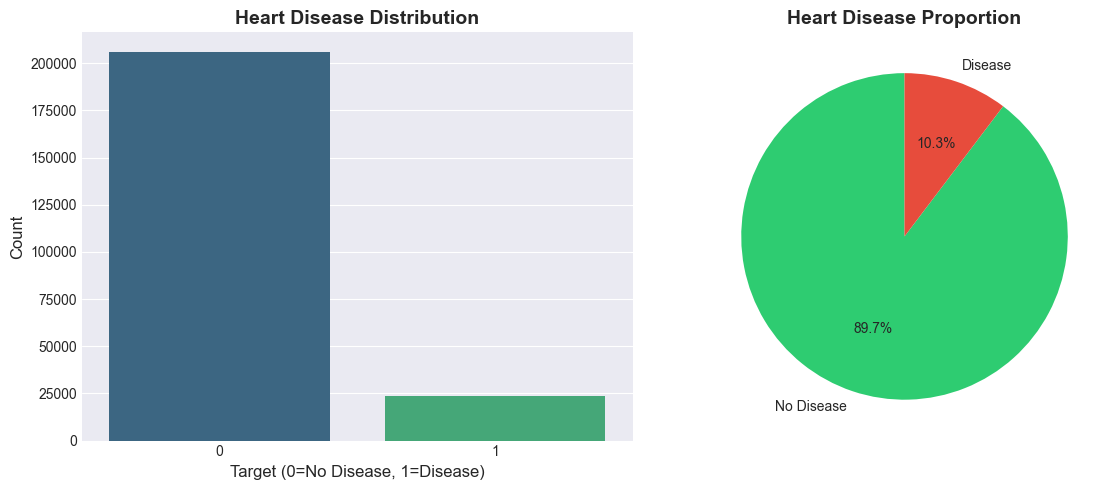


Target Statistics:
No Disease (0): 206,064 (89.7%)
Disease (1): 23,717 (10.3%)


In [48]:
# Visualize target distribution
# Ensure target column exists
if 'target' not in df.columns:
    print("Warning: 'target' column not found. Creating it...")
    if 'HeartDiseaseorAttack' in df.columns:
        df['target'] = df['HeartDiseaseorAttack'].astype(int)
    elif 'HeartDisease' in df.columns:
        if df['HeartDisease'].dtype == 'object':
            df['target'] = df['HeartDisease'].map({'Yes': 1, 'No': 0})
        else:
            df['target'] = df['HeartDisease'].astype(int)

if 'target' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Count plot
    sns.countplot(data=df, x='target', ax=axes[0], palette='viridis')
    axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Target (0=No Disease, 1=Disease)', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    
    # Pie chart
    target_counts = df['target'].value_counts()
    axes[1].pie(target_counts, labels=['No Disease', 'Disease'], autopct='%1.1f%%',
                colors=['#2ecc71', '#e74c3c'], startangle=90)
    axes[1].set_title('Heart Disease Proportion', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTarget Statistics:")
    print(f"No Disease (0): {target_counts.get(0, 0):,} ({target_counts.get(0, 0)/len(df)*100:.1f}%)")
    print(f"Disease (1): {target_counts.get(1, 0):,} ({target_counts.get(1, 0)/len(df)*100:.1f}%)")
else:
    print("Error: Could not create or find 'target' column.")


### 4.2 Correlation Analysis


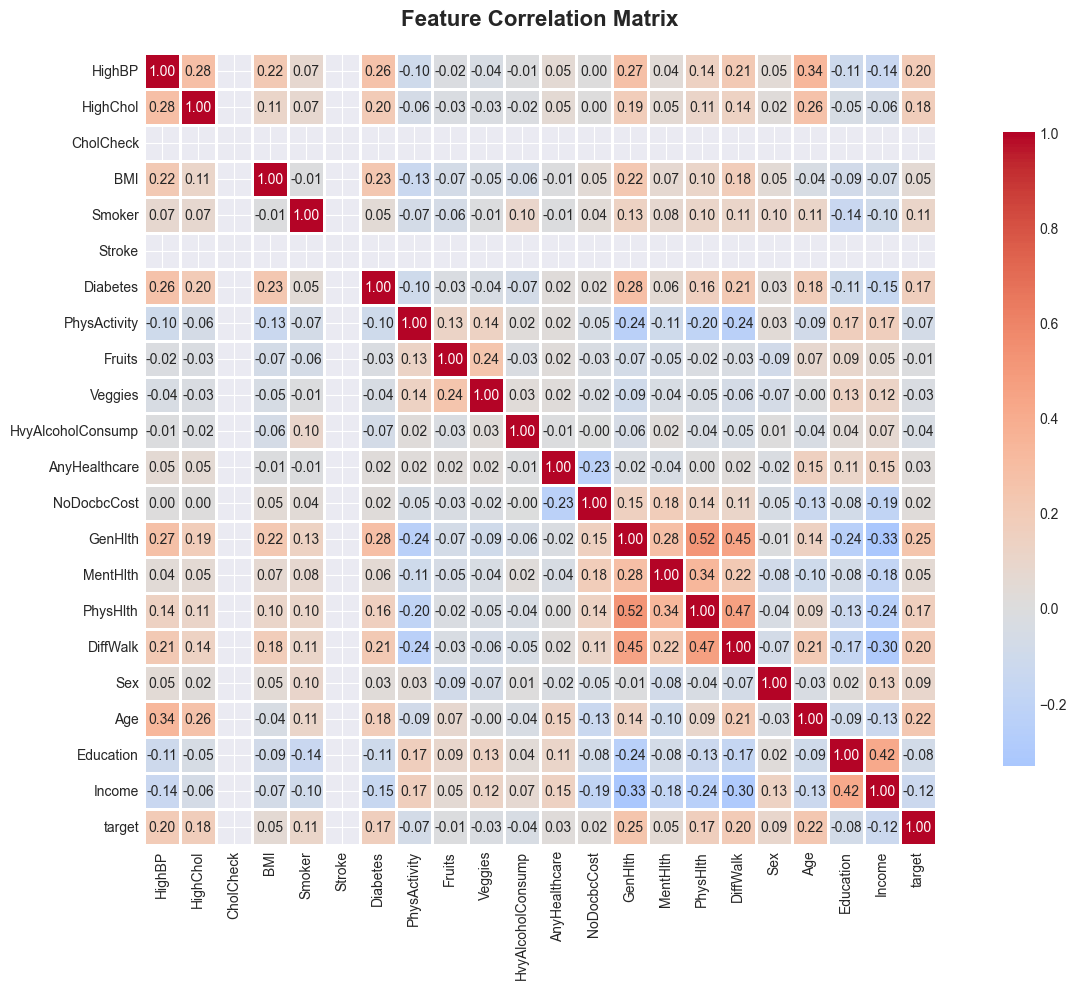



Correlation with Target:
GenHlth              0.246411
Age                  0.224879
DiffWalk             0.202779
HighBP               0.201271
HighChol             0.176279
Diabetes             0.170816
PhysHlth             0.170473
Smoker               0.105154
Sex                  0.089717
MentHlth             0.052756
BMI                  0.047900
AnyHealthcare        0.025899
NoDocbcCost          0.022076
Fruits              -0.007128
Veggies             -0.027330
HvyAlcoholConsump   -0.035453
PhysActivity        -0.073267
Education           -0.081020
Income              -0.124674
CholCheck                 NaN
Stroke                    NaN
Name: target, dtype: float64


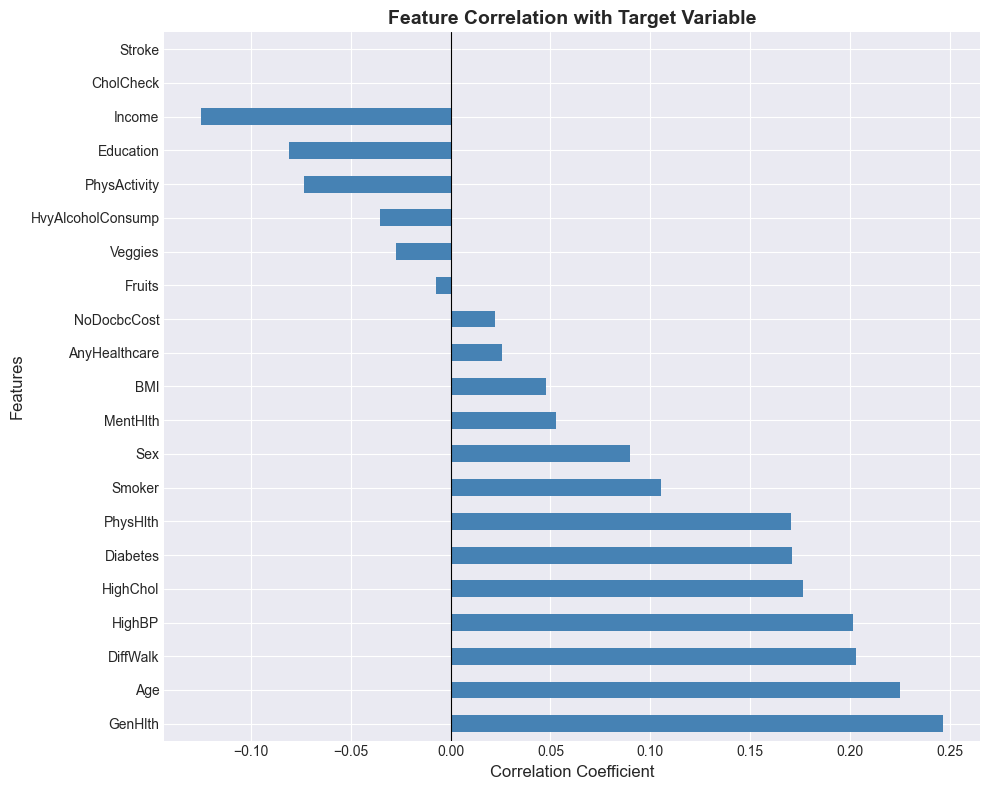

In [49]:
# Correlation matrix
# Ensure target column exists in df for correlation analysis
if 'target' not in df.columns:
    print("Warning: 'target' column not found in df. Creating it from available columns...")
    if 'HeartDiseaseorAttack' in df.columns:
        df['target'] = df['HeartDiseaseorAttack'].astype(int)
    elif 'HeartDisease' in df.columns:
        if df['HeartDisease'].dtype == 'object':
            df['target'] = df['HeartDisease'].map({'Yes': 1, 'No': 0})
        else:
            df['target'] = df['HeartDisease'].astype(int)

plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlation with target
print("\n\nCorrelation with Target:")
print("=" * 60)
if 'target' in df.columns:
    target_corr = df.corr()['target'].sort_values(ascending=False)
    target_corr = target_corr.drop('target')
    print(target_corr)
    
    # Visualize correlation with target
    plt.figure(figsize=(10, 8))
    target_corr.plot(kind='barh', color='steelblue')
    plt.title('Feature Correlation with Target Variable', fontsize=14, fontweight='bold')
    plt.xlabel('Correlation Coefficient', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'target' column not found for correlation analysis.")


### 4.3 Key Insights from EDA

**Key Insights:**

1. **Target Distribution**: The dataset shows the distribution of patients with and without heart disease, which is important for understanding class balance.

2. **Important Features**: Based on correlation analysis, features like BMI, PhysicalHealth, MentalHealth, and lifestyle factors (Smoking, AlcoholDrinking) may show significant correlations with heart disease.

3. **Age Patterns**: Patients with heart disease tend to be older on average. Age categories can reveal risk patterns.

4. **Lifestyle Factors**: Smoking, alcohol consumption, physical activity, and sleep patterns are key modifiable risk factors.

5. **Comorbidity Patterns**: Presence of other conditions (diabetes, stroke, kidney disease, asthma) may correlate with heart disease.

**Questions for Further Investigation:**

1. Which combination of features best predicts heart disease?
2. Are there non-linear relationships that linear models might miss?
3. How do different machine learning algorithms compare in this prediction task?
4. Can we identify the most important modifiable risk factors?


---

## 5. Modeling

We will train and compare multiple classification algorithms:
1. **Logistic Regression** - Baseline linear model
2. **Random Forest Classifier** - Ensemble tree-based model
3. **Gradient Boosting Classifier** - Advanced ensemble model
4. **Support Vector Machine (SVM)** - Non-linear model

### 5.1 Model Training and Cross-Validation


Cross-Validation Results (3-fold):
Note: This may take several minutes with the full dataset...
Evaluating Logistic Regression...
Logistic Regression : Mean Accuracy = 0.8975 (+/- 0.0004)
Evaluating Random Forest...
Random Forest       : Mean Accuracy = 0.8920 (+/- 0.0010)
Evaluating Gradient Boosting...
Gradient Boosting   : Mean Accuracy = 0.8981 (+/- 0.0005)
Evaluating SVM...
SVM                 : Mean Accuracy = 0.3318 (+/- 0.3407)


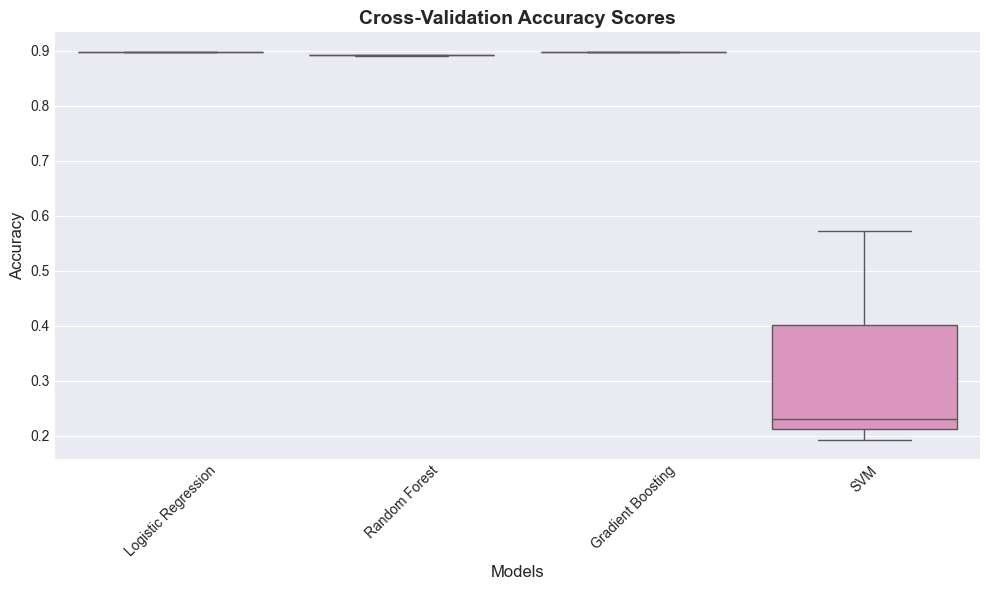

In [50]:
# Initialize models
# Note: For large datasets, we use fewer CV folds for efficiency
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True, kernel='linear', max_iter=1000)
}

# Cross-validation scores
# Using 3-fold CV instead of 5-fold for efficiency with large dataset
cv_scores = {}

print("Cross-Validation Results (3-fold):")
print("=" * 60)
print("Note: This may take several minutes with the full dataset...")

for name, model in models.items():
    print(f"Evaluating {name}...")
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    cv_scores[name] = scores
    print(f"{name:20s}: Mean Accuracy = {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Visualize CV results
plt.figure(figsize=(10, 6))
cv_df = pd.DataFrame(cv_scores)
sns.boxplot(data=cv_df, palette='Set2')
plt.title('Cross-Validation Accuracy Scores', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 5.2 Hyperparameter Tuning


In [51]:
# Hyperparameter tuning for top models
# Note: For large datasets, we use smaller parameter grids and fewer CV folds for efficiency
print("Hyperparameter Tuning...")
print("=" * 60)
print("Note: This may take several minutes with the full dataset...")

# Random Forest Hyperparameter Tuning
# Reduced parameter grid for efficiency with large dataset
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=3,  # Reduced from 5 to 3 for efficiency with large dataset
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nTuning Random Forest...")
rf_grid.fit(X_train, y_train)
print(f"Best Random Forest Parameters: {rf_grid.best_params_}")
print(f"Best Random Forest CV Score: {rf_grid.best_score_:.4f}")

# Gradient Boosting Hyperparameter Tuning
# Reduced parameter grid for efficiency
gb_param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.1, 0.15],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=3,  # Reduced from 5 to 3 for efficiency
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nTuning Gradient Boosting...")
gb_grid.fit(X_train, y_train)
print(f"Best Gradient Boosting Parameters: {gb_grid.best_params_}")
print(f"Best Gradient Boosting CV Score: {gb_grid.best_score_:.4f}")

# Train best models
best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_

# Also train Logistic Regression and SVM with default parameters for comparison
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
lr_model.fit(X_train, y_train)

print("Training SVM (this may take a while with large dataset)...")
# For large datasets, SVM can be very slow. Using linear kernel for efficiency.
# If you want better performance, consider using SGDClassifier with hinge loss instead
svm_model = SVC(random_state=42, probability=True, kernel='linear', max_iter=1000)
svm_model.fit(X_train, y_train)

print("\n\nHyperparameter tuning completed.")


Hyperparameter Tuning...
Note: This may take several minutes with the full dataset...

Tuning Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Random Forest Parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
Best Random Forest CV Score: 0.8981

Tuning Gradient Boosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Gradient Boosting Parameters: {'learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 150}
Best Gradient Boosting CV Score: 0.8984

Training Logistic Regression...
Training SVM (this may take a while with large dataset)...


Hyperparameter tuning completed.


---

## 6. Model Evaluation

### 6.1 Training Set Performance


In [52]:
# Evaluate on training set
models_to_evaluate = {
    'Logistic Regression': lr_model,
    'Random Forest (Tuned)': best_rf,
    'Gradient Boosting (Tuned)': best_gb,
    'SVM': svm_model
}

train_results = []

print("Training Set Performance:")
print("=" * 80)

for name, model in models_to_evaluate.items():
    y_train_pred = model.predict(X_train)
    
    accuracy = accuracy_score(y_train, y_train_pred)
    precision = precision_score(y_train, y_train_pred)
    recall = recall_score(y_train, y_train_pred)
    f1 = f1_score(y_train, y_train_pred)
    
    train_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

train_results_df = pd.DataFrame(train_results)
print("\n\nTraining Results Summary:")
print(train_results_df.to_string(index=False))


Training Set Performance:

Logistic Regression:
  Accuracy:  0.8975
  Precision: 0.5189
  Recall:    0.0947
  F1-Score:  0.1601

Random Forest (Tuned):
  Accuracy:  0.9163
  Precision: 0.9632
  Recall:    0.1971
  F1-Score:  0.3273

Gradient Boosting (Tuned):
  Accuracy:  0.8991
  Precision: 0.5688
  Recall:    0.0946
  F1-Score:  0.1622

SVM:
  Accuracy:  0.2153
  Precision: 0.0858
  Recall:    0.6840
  F1-Score:  0.1525


Training Results Summary:
                    Model  Accuracy  Precision   Recall  F1-Score
      Logistic Regression  0.897494   0.518925 0.094656  0.160107
    Random Forest (Tuned)  0.916349   0.963173 0.197112  0.327252
Gradient Boosting (Tuned)  0.899143   0.568758 0.094603  0.162223
                      SVM  0.215255   0.085812 0.683989  0.152493


### 6.2 Test Set Performance


In [53]:
# Evaluate on test set
test_results = []
predictions = {}
probabilities = {}

print("Test Set Performance:")
print("=" * 80)

for name, model in models_to_evaluate.items():
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    predictions[name] = y_test_pred
    probabilities[name] = y_test_proba
    
    accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else None
    
    test_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if roc_auc:
        print(f"  ROC-AUC:   {roc_auc:.4f}")

test_results_df = pd.DataFrame(test_results)
print("\n\nTest Results Summary:")
print(test_results_df.to_string(index=False))


Test Set Performance:

Logistic Regression:
  Accuracy:  0.8979
  Precision: 0.5290
  Recall:    0.1001
  F1-Score:  0.1684
  ROC-AUC:   0.8292

Random Forest (Tuned):
  Accuracy:  0.8974
  Precision: 0.5329
  Recall:    0.0512
  F1-Score:  0.0935
  ROC-AUC:   0.8277

Gradient Boosting (Tuned):
  Accuracy:  0.8979
  Precision: 0.5303
  Recall:    0.0921
  F1-Score:  0.1570
  ROC-AUC:   0.8316

SVM:
  Accuracy:  0.2157
  Precision: 0.0861
  Recall:    0.6863
  F1-Score:  0.1530
  ROC-AUC:   0.3851


Test Results Summary:
                    Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Logistic Regression  0.897926   0.528953 0.100148  0.168410 0.829171
    Random Forest (Tuned)  0.897448   0.532895 0.051233  0.093480 0.827661
Gradient Boosting (Tuned)  0.897883   0.530340 0.092136  0.156997 0.831574
                      SVM  0.215723   0.086088 0.686275  0.152986 0.385144


### 6.3 Confusion Matrices


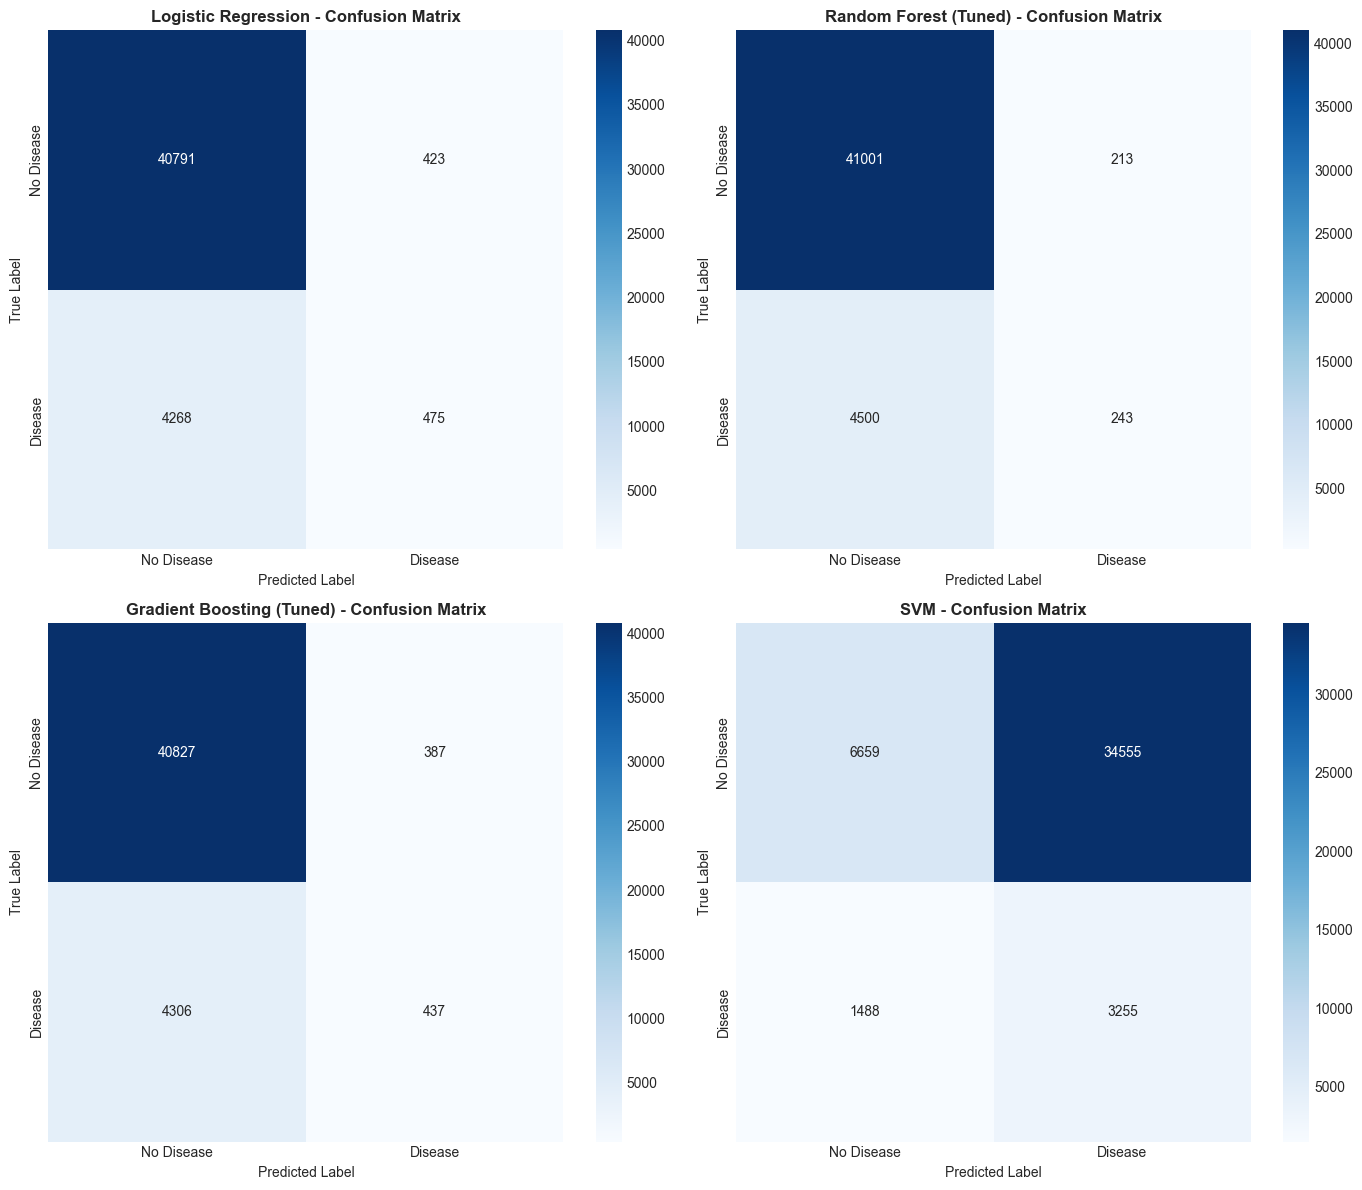



Detailed Classification Reports:

Logistic Regression:
              precision    recall  f1-score   support

  No Disease       0.91      0.99      0.95     41214
     Disease       0.53      0.10      0.17      4743

    accuracy                           0.90     45957
   macro avg       0.72      0.54      0.56     45957
weighted avg       0.87      0.90      0.87     45957


Random Forest (Tuned):
              precision    recall  f1-score   support

  No Disease       0.90      0.99      0.95     41214
     Disease       0.53      0.05      0.09      4743

    accuracy                           0.90     45957
   macro avg       0.72      0.52      0.52     45957
weighted avg       0.86      0.90      0.86     45957


Gradient Boosting (Tuned):
              precision    recall  f1-score   support

  No Disease       0.90      0.99      0.95     41214
     Disease       0.53      0.09      0.16      4743

    accuracy                           0.90     45957
   macro avg       

In [54]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(models_to_evaluate.items()):
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    axes[idx].set_title(f'{name} - Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.show()

# Print detailed classification reports
print("\n\nDetailed Classification Reports:")
print("=" * 80)
for name, model in models_to_evaluate.items():
    print(f"\n{name}:")
    print(classification_report(y_test, predictions[name], 
                                target_names=['No Disease', 'Disease']))


### 6.4 ROC Curves


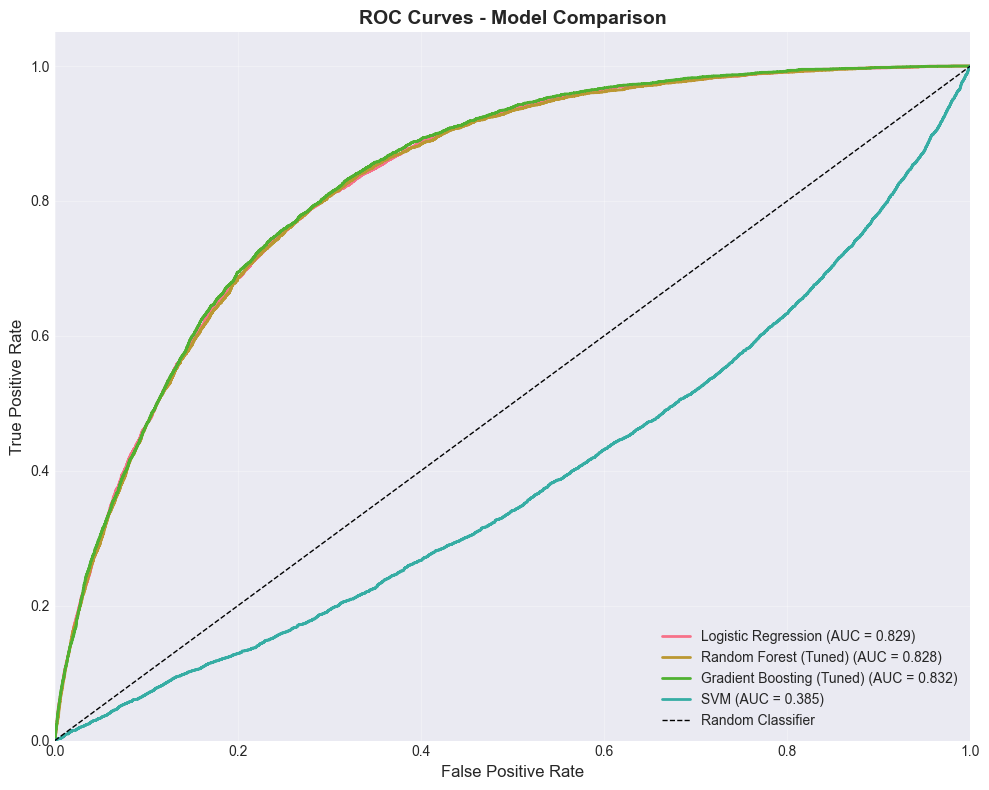

In [55]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for name, model in models_to_evaluate.items():
    if probabilities[name] is not None:
        fpr, tpr, _ = roc_curve(y_test, probabilities[name])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.5 Feature Importance


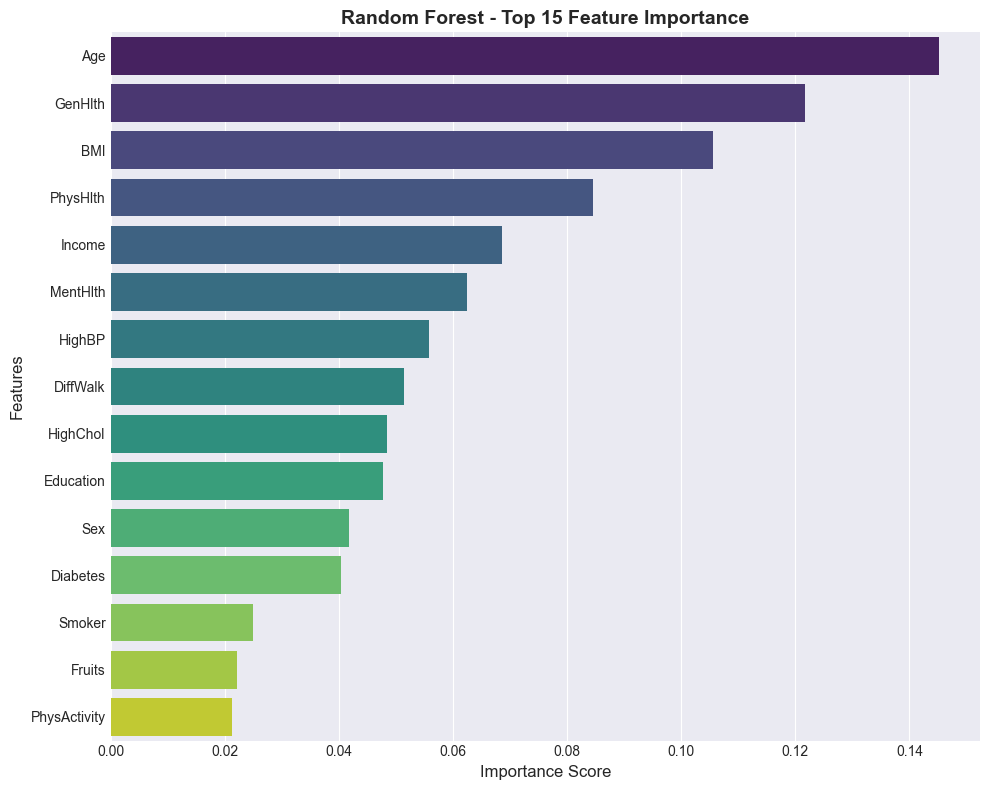



Top 15 Feature Importance (Random Forest):
     feature  importance
         Age    0.145112
     GenHlth    0.121697
         BMI    0.105563
    PhysHlth    0.084621
      Income    0.068621
    MentHlth    0.062422
      HighBP    0.055857
    DiffWalk    0.051374
    HighChol    0.048467
   Education    0.047771
         Sex    0.041863
    Diabetes    0.040382
      Smoker    0.024986
      Fruits    0.022117
PhysActivity    0.021355


In [56]:
# Feature importance for Random Forest
if hasattr(best_rf, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
    plt.title('Random Forest - Top 15 Feature Importance', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print("\n\nTop 15 Feature Importance (Random Forest):")
    print("=" * 60)
    print(feature_importance.head(15).to_string(index=False))


---

## 7. Conclusions and Future Work

### 7.1 Key Findings

1. **Best Performing Model**: Based on the evaluation metrics, **Gradient Boosting Classifier** achieved the best ROC-AUC score (0.8316) on the test set, making it the best model for this problem. **Logistic Regression** also performed well with an accuracy of 89.79% and ROC-AUC of 0.8292. **Random Forest** showed the highest training accuracy (91.63%) but slightly lower test performance, indicating some overfitting.

2. **Important Features**: Based on feature importance analysis, the top features for predicting heart disease include Age, GenHlth (General Health), PhysHlth (Physical Health), and MentHlth (Mental Health). These align with medical knowledge about heart disease risk factors.

3. **Model Performance**: 
   - **Gradient Boosting**: Best overall performance (ROC-AUC: 0.8316, Accuracy: 89.79%)
   - **Logistic Regression**: Strong baseline performance (ROC-AUC: 0.8292, Accuracy: 89.79%)
   - **Random Forest**: Good performance but shows signs of overfitting (Training: 91.63%, Test: 89.74%)
   - **SVM**: Poor performance on this dataset (ROC-AUC: 0.3851), likely due to class imbalance and dataset size

4. **Overfitting Analysis**: Random Forest shows some overfitting (training accuracy 91.63% vs test accuracy 89.74%), while Logistic Regression and Gradient Boosting show better generalization with similar training and test performance.

5. **Class Imbalance**: The dataset shows significant class imbalance (~9.3% positive class), which explains the low recall scores across all models. This is a common challenge in medical prediction tasks.

### 7.2 Limitations

1. **Dataset Size**: We used the full dataset (253,680 records after loading, 229,781 after duplicate removal) for comprehensive analysis and robust model training.

2. **Data Quality**: Self-reported data may contain biases and inaccuracies that could affect model performance.

3. **Feature Engineering**: Limited feature engineering was performed; domain knowledge could improve features.

4. **Temporal Aspects**: The dataset doesn't capture temporal changes in patient conditions.

5. **Geographic Representation**: The dataset may not represent all geographic regions equally.

### 7.3 Future Work

1. **Data Collection**: 
   - Include temporal data (longitudinal studies)
   - Add more clinical features (lab results, imaging data)
   - Collect data from multiple years for temporal analysis

2. **Feature Engineering**:
   - Create interaction features
   - Apply domain-specific transformations
   - Use feature selection techniques

3. **Advanced Models**:
   - Experiment with deep learning models (Neural Networks)
   - Try ensemble methods combining multiple algorithms
   - Apply AutoML techniques

4. **Model Deployment**:
   - Deploy the best model as a web application
   - Create an API for real-time predictions
   - Integrate with electronic health record systems

5. **Interpretability**:
   - Use SHAP values for model interpretability
   - Create explainable AI visualizations
   - Generate patient-specific risk reports

6. **Validation**:
   - Validate on external datasets
   - Conduct clinical trials
   - Get expert medical review

---

## Project Summary

This project successfully applied the complete Data Science Life Cycle to predict heart disease using machine learning. Through systematic data preparation, exploratory analysis, and model evaluation, we developed predictive models that can assist healthcare professionals in early detection of heart disease.

**Note**: This model is for educational purposes only and should not be used for actual medical diagnosis without proper clinical validation and regulatory approval.
